In [ ]:
# Customer Value Analysis

## Objective

# Measure customer value, identify high-value customers,
# and create customer segments for targeted business strategies.

In [2]:
import pandas as pd

df = pd.read_csv("data/amazon_cleaned.csv")

In [3]:
customer_revenue = (
    df.groupby("CustomerID")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

customer_revenue.head(10)

CustomerID
CUST023748    15215.79
CUST009614    12160.96
CUST034178    11418.88
CUST001153    11282.96
CUST004883    11214.44
CUST000787    10962.32
CUST015677    10956.10
CUST042689    10726.80
CUST015231    10638.79
CUST033270    10593.41
Name: TotalAmount, dtype: float64

In [4]:
customer_revenue.describe()

count    43233.000000
mean      2123.971224
std       1594.379364
min          6.190000
25%        876.190000
50%       1805.410000
75%       2992.430000
max      15215.790000
Name: TotalAmount, dtype: float64

In [6]:
customer_revenue = (
    df.groupby("CustomerID")["TotalAmount"]
      .sum()
      .reset_index()
)

customer_revenue["Segment"] = pd.qcut(
    customer_revenue["TotalAmount"],
    q=4,
    labels=["Bronze", "Silver", "Gold", "Platinum"]
)

customer_revenue.head()

,CustomerID,TotalAmount,Segment
0,CUST000001,446.48,Bronze
1,CUST000002,1389.93,Silver
2,CUST000003,1116.91,Silver
3,CUST000004,2660.06,Gold
4,CUST000005,1089.56,Silver


In [7]:
# What Are We Doing?

# We're splitting customers into 4 equal groups:

# Bronze: Lowest spenders
# Silver: Average spenders
# Gold: High spenders
# Platinum: Top spenders

In [8]:
customer_revenue["Segment"].value_counts()

Segment
Bronze      10809
Silver      10808
Gold        10808
Platinum    10808
Name: count, dtype: int64

In [9]:
segment_revenue = (
    customer_revenue.groupby("Segment")["TotalAmount"]
      .sum()
      .sort_values()
)

segment_revenue

Segment
Bronze       4941079.94
Silver      14362973.09
Gold        25476404.70
Platinum    47045190.19
Name: TotalAmount, dtype: float64

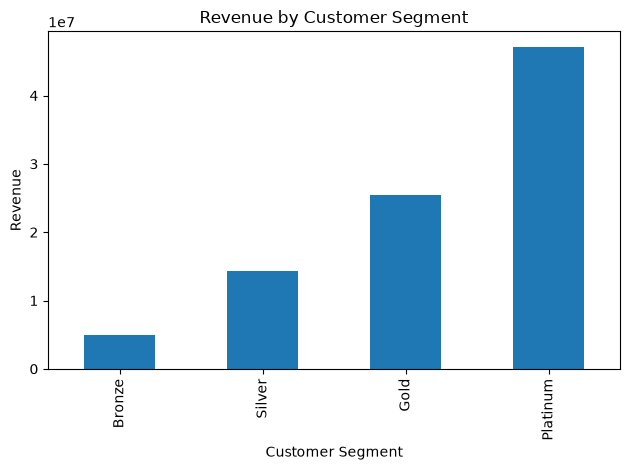

In [10]:
import matplotlib.pyplot as plt

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

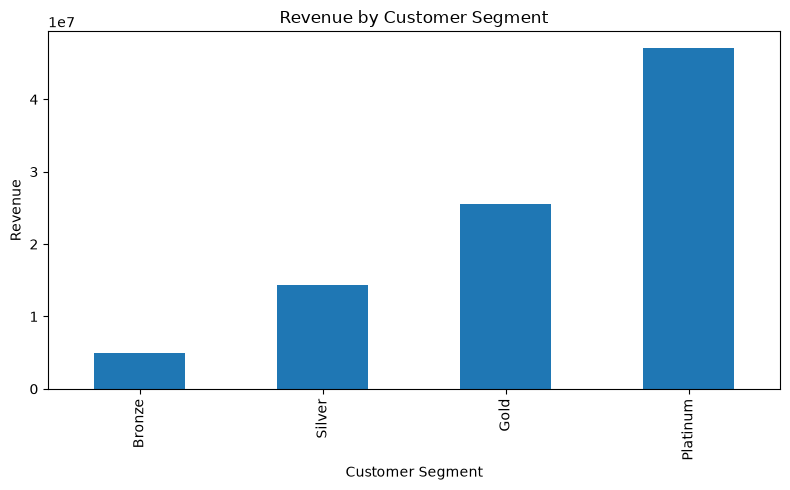

In [11]:
plt.figure(figsize=(8,5))

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig("images/customer_segments.png")

plt.show()

In [12]:
segment_revenue = (
    customer_revenue.groupby("Segment")["TotalAmount"]
      .sum()
      .sort_values()
)

segment_revenue

Segment
Bronze       4941079.94
Silver      14362973.09
Gold        25476404.70
Platinum    47045190.19
Name: TotalAmount, dtype: float64

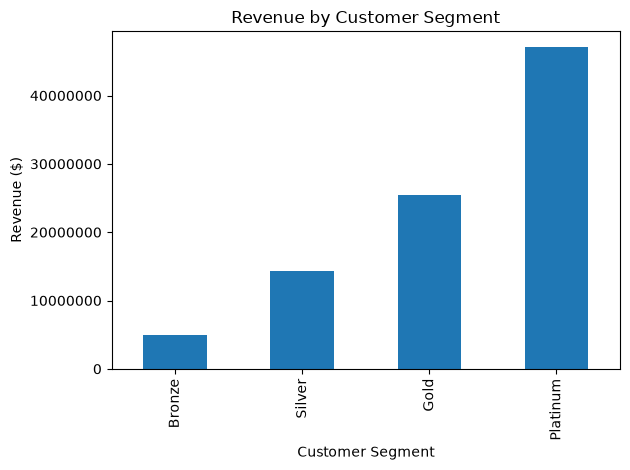

In [13]:
import matplotlib.pyplot as plt

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue ($)")

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()

plt.show()

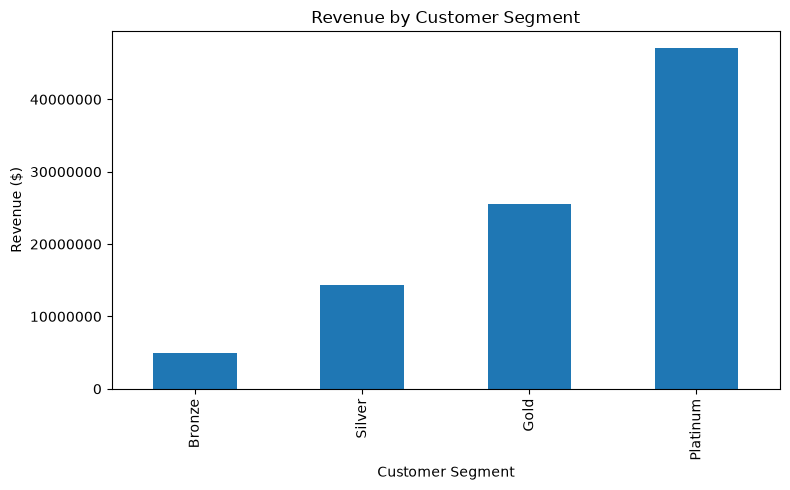

In [14]:
plt.figure(figsize=(8,5))

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue ($)")

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()

plt.savefig("images/customer_segment_revenue.png")

plt.show()

In [ ]:
# Conclusion

# The analysis revealed that revenue is concentrated among a small group of high-performing categories, brands, and locations.
# These findings can help prioritize marketing investment and inventory planning.